In [2]:
#Setup
!pip install pyspark -q
!pip install kaggle -q
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = SparkSession.builder.appName("OlistJoins").getOrCreate()


In [3]:
#Loading all the tables
orders = spark.read.csv('/content/olist_orders_dataset.csv', header=True, inferSchema=True)
order_items = spark.read.csv('/content/olist_order_items_dataset.csv', header=True, inferSchema=True)
products = spark.read.csv('/olist_products_dataset.csv', header=True, inferSchema=True)
customers = spark.read.csv('/content/olist_customers_dataset.csv', header=True, inferSchema=True)
payments = spark.read.csv('/content/olist_order_payments_dataset.csv', header=True, inferSchema=True)
reviews = spark.read.csv('/content/olist_order_reviews_dataset.csv', header=True, inferSchema=True)
category_translation = spark.read.csv('/content/product_category_name_translation.csv', header=True, inferSchema=True)

print("Orders:", orders.count())
print("Order Items:", order_items.count())
print("Products:", products.count())

Orders: 99441
Order Items: 112650
Products: 32951


In [4]:
#Cleaning Each Table Before Joining
# Drop duplicate rows and nulls in join keys — critical before any join
orders = orders.dropDuplicates(['order_id']).na.drop(subset=['order_id', 'customer_id'])
order_items = order_items.dropDuplicates().na.drop(subset=['order_id', 'product_id'])
products = products.dropDuplicates(['product_id']).na.drop(subset=['product_id'])
customers = customers.dropDuplicates(['customer_id']).na.drop(subset=['customer_id'])
payments = payments.dropDuplicates().na.drop(subset=['order_id'])
reviews = reviews.dropDuplicates(['review_id']).na.drop(subset=['order_id'])

# Convert date columns
orders = orders.withColumn('order_purchase_timestamp', F.to_timestamp('order_purchase_timestamp')) \
               .withColumn('order_delivered_customer_date', F.to_timestamp('order_delivered_customer_date')) \
               .withColumn('order_estimated_delivery_date', F.to_timestamp('order_estimated_delivery_date'))

In [5]:
#PySpark Joins: Building the Full Order View
# INNER JOIN: orders + order_items (every order must have items)
orders_items = orders.join(order_items, on='order_id', how='inner')

# INNER JOIN: bring in product details
orders_items_products = orders_items.join(products, on='product_id', how='inner')

# LEFT JOIN: add category name in English (some products may lack a translation)
orders_full = orders_items_products.join(category_translation, on='product_category_name', how='left')

# INNER JOIN: bring in customer details
orders_full = orders_full.join(customers, on='customer_id', how='inner')

# LEFT JOIN: payments (a few orders may have missing payment records)
orders_full = orders_full.join(payments, on='order_id', how='left')

# LEFT JOIN: reviews (not every order has a review)
orders_full = orders_full.join(
    reviews.select('order_id', 'review_score'), on='order_id', how='left'
)

# Add a delivery delay column (actual vs estimated)
orders_full = orders_full.withColumn(
    'delivery_delay_days',
    F.datediff('order_delivered_customer_date', 'order_estimated_delivery_date')
)

print("Final joined row count:", orders_full.count())
orders_full.select('order_id', 'product_category_name_english', 'price',
                    'payment_value', 'review_score', 'delivery_delay_days').show(5)

Final joined row count: 117933
+--------------------+-----------------------------+-----+-------------+------------+-------------------+
|            order_id|product_category_name_english|price|payment_value|review_score|delivery_delay_days|
+--------------------+-----------------------------+-----+-------------+------------+-------------------+
|00ed64bc080d87b4a...|                         NULL| 44.9|        61.01|           5|                -15|
|048f4f6b6d2d3bc13...|         kitchen_dining_la...| 48.9|         86.8|           5|                -11|
|048fec87f5858e3a9...|                   housewares|42.42|       304.33|           5|                -15|
|054df8d1a5ab3cf52...|                  electronics| 12.9|        59.92|           2|                -12|
|059bbeb3477ed66fd...|                         auto| 31.0|        42.85|           5|                -19|
+--------------------+-----------------------------+-----+-------------+------------+-------------------+
only showing to

In [6]:
#Converting to Pandas for Visualization
# Select only the columns needed to keep this lightweight before converting
final_cols = ['order_id', 'customer_state', 'product_category_name_english',
              'price', 'payment_value', 'payment_type', 'review_score',
              'delivery_delay_days', 'order_purchase_timestamp']

df = orders_full.select(final_cols).toPandas()
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df.head()

,order_id,customer_state,product_category_name_english,price,payment_value,payment_type,review_score,delivery_delay_days,order_purchase_timestamp
0,00018f77f2f0320c557190d7a144bdd3,SP,pet_shop,239.90,259.83,credit_card,4,-3.0,2017-04-26 10:53:06
1,000229ec398224ef6ca0657da4fc703e,MG,furniture_decor,199.00,216.87,credit_card,5,-14.0,2018-01-14 14:33:31
2,00024acbcdf0a6daa1e931b038114c75,SP,perfumery,12.99,25.78,credit_card,4,-6.0,2018-08-08 10:00:35
3,00042b26cf59d7ce69dfabb4e55b4fd9,SP,garden_tools,199.90,218.04,credit_card,5,-16.0,2017-02-04 13:57:51
4,00054e8431b9d7675808bcb819fb4a32,SP,telephony,19.90,31.75,credit_card,4,-17.0,2017-12-10 11:53:48


In [8]:
#Equivalent Join in Pandas (Showing Both Approaches)
# Reading a couple of the same CSVs directly into Pandas to demonstrate
# the equivalent merge() logic for smaller-scale joins
orders_pd = pd.read_csv('/content/olist_orders_dataset.csv')
items_pd = pd.read_csv('/content/olist_order_items_dataset.csv')
products_pd = pd.read_csv('/olist_products_dataset.csv')

# Pandas equivalent of an inner join
merged_pd = orders_pd.merge(items_pd, on='order_id', how='inner') \
                      .merge(products_pd, on='product_id', how='inner')

print("Pandas merged shape:", merged_pd.shape)
merged_pd.head(3)

Pandas merged shape: (112650, 22)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0


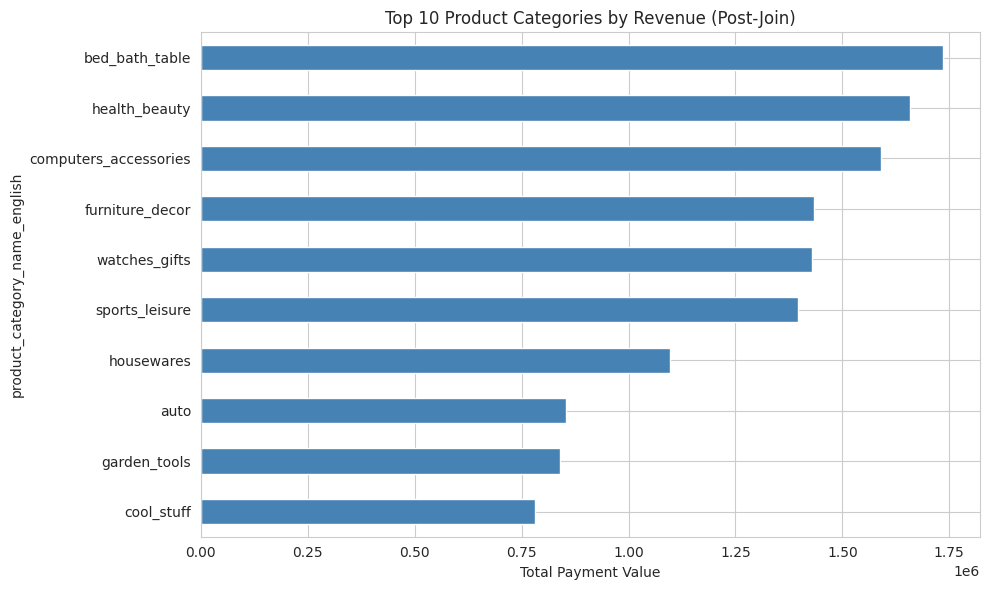

In [9]:
#Post-Join Visualization: Revenue by Category
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

top_categories = df.groupby('product_category_name_english')['payment_value'] \
                    .sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_categories.plot(kind='barh', color='steelblue')
plt.title('Top 10 Product Categories by Revenue (Post-Join)')
plt.xlabel('Total Payment Value')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

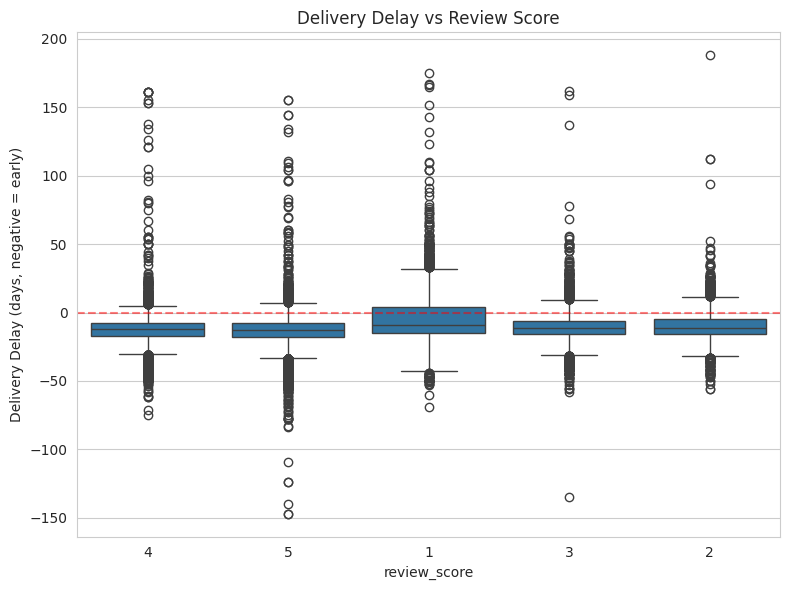

In [10]:
#Post-Join Visualization: Review Score vs Delivery Delay
plt.figure(figsize=(8,6))
sns.boxplot(data=df.dropna(subset=['review_score', 'delivery_delay_days']),
            x='review_score', y='delivery_delay_days')
plt.title('Delivery Delay vs Review Score')
plt.ylabel('Delivery Delay (days, negative = early)')
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

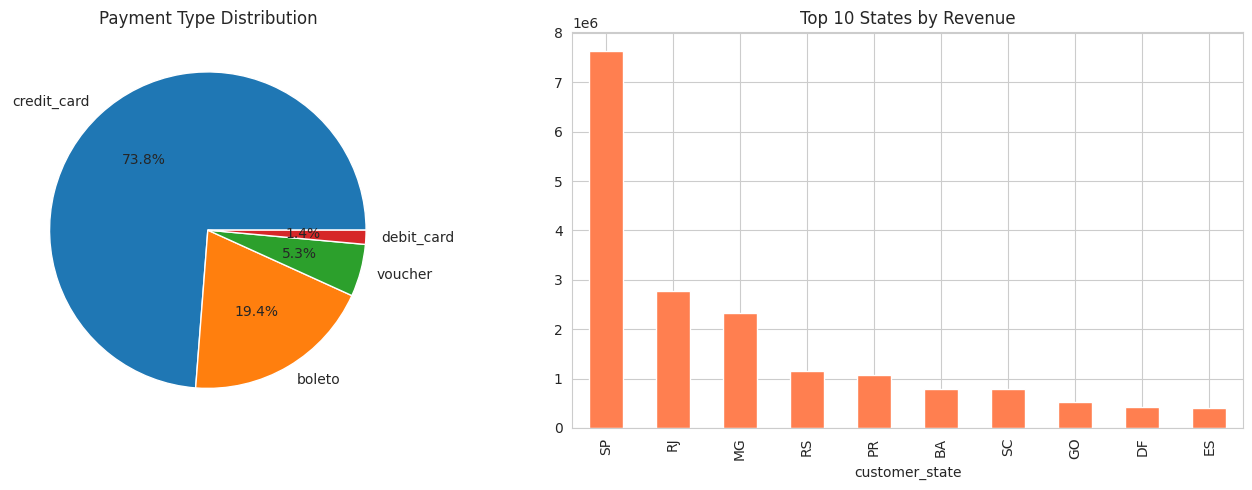

In [11]:
#Post-Join Visualization: Payment Type & Regional Spend
fig, axes = plt.subplots(1, 2, figsize=(14,5))

df['payment_type'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[0])
axes[0].set_title('Payment Type Distribution')
axes[0].set_ylabel('')

state_revenue = df.groupby('customer_state')['payment_value'].sum().sort_values(ascending=False).head(10)
state_revenue.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Top 10 States by Revenue')

plt.tight_layout()
plt.show()

In [12]:
#Export
df.to_csv('olist_joined_analysis.csv', index=False)
from google.colab import files
files.download('olist_joined_analysis.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>